importing libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as mp
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


loading the model

In [3]:
cnn = tf.keras.models.load_model('./trained_model.keras')

I0000 00:00:1776805070.619425   15167 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


reading image for prediction

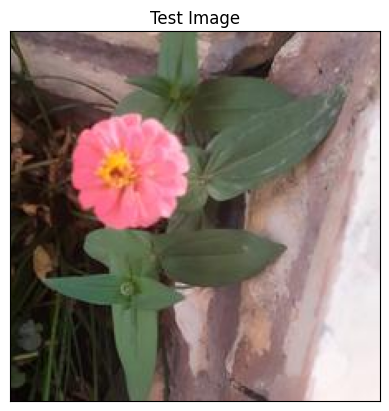

In [ ]:
import cv2
image_path = './test/Rain Lily/(Rain Lily).jpeg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
mp.imshow(img)
mp.title('Test Image')
mp.xticks([])
mp.yticks([])
mp.show()

test image

In [57]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(224,224))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [58]:
print(predictions)
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

[[1.6381580e-07 1.4882616e-09 2.1443378e-11 1.6550528e-09 9.9999988e-01]]
4


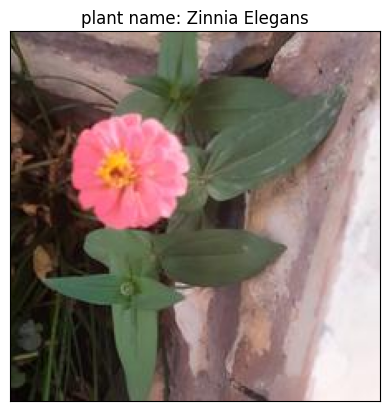

In [60]:
class_names = ['Damask Rose','Echeveria Flower','Mirabilis Jalapa','Rain Lily','Zinnia Elegans']
model_prediction = class_names[result_index]
mp.imshow(img)
mp.title(f"plant name: {model_prediction}")
mp.xticks([])
mp.yticks([])
mp.show()